In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import(
accuracy_score,
precision_score,
recall_score,
f1_score,
confusion_matrix,
roc_curve,
auc
)



In [8]:
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

mle_model=LogisticRegression(
    penalty=None,
    max_iter=5000,
    random_state=42)

mle_model.fit(x_train,y_train)

y_pred_mle=mle_model.predict(x_test)

In [13]:
map_l2=LogisticRegression(
    penalty='l2',
    C=1.0, 
    solver='lbfgs',
    max_iter=5000, 
    random_state=42, 
) 
map_l2.fit(x_train,y_train), 
y_pred_l2=map_l2.predict(x_test)

In [15]:
map_l1=LogisticRegression(
  penalty='l1',
  solver='liblinear',
  C=1.0,
  max_iter=5000, 
  random_state=42
)
map_l1.fit(x_train,y_train),
y_pred_l1=map_l1.predict(x_test)


In [17]:
def evaluate(model_name,y_true,y_pred):
    print("\n","="*40)
    print(model_name)
    print("="*40)

    print("Accuracy:",accuracy_score(y_true,y_pred))
    print("Precision:",precision_score(y_true,y_pred))
    print("Recall:",recall_score(y_true,y_pred))
    print("F1_score:",f1_score(y_true,y_pred))


    print("\nConfusion Matrix")
    print(confusion_matrix(y_true,y_pred))

    
evaluate("MLE",y_test,y_pred_mle)
evaluate("MAP(L2)",y_test,y_pred_l2)
evaluate("MAP(L1)",y_test,y_pred_l1)


    

        
    


MLE
Accuracy: 0.9210526315789473
Precision: 0.9701492537313433
Recall: 0.9027777777777778
F1_score: 0.935251798561151

Confusion Matrix
[[40  2]
 [ 7 65]]

MAP(L2)
Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1_score: 0.9861111111111112

Confusion Matrix
[[41  1]
 [ 1 71]]

MAP(L1)
Accuracy: 0.9912280701754386
Precision: 0.9863013698630136
Recall: 1.0
F1_score: 0.993103448275862

Confusion Matrix
[[41  1]
 [ 0 72]]


In [18]:
print("Number of zero coefficients")
print("MLE :",np.sum(mle_model.coef_[0]==0))
print("MAP L2 :",np.sum(map_l2.coef_[0]==0))
print("MAP L1 :",np.sum(map_l1.coef_[0]==0))

Number of zero coefficients
MLE : 0
MAP L2 : 0
MAP L1 : 14


In [24]:
results = pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1_score"
])

models = [
    ("MLE", mle_model, y_pred_mle),
    ("MAP L2", map_l2, y_pred_l2),
    ("MAP L1", map_l1, y_pred_l1)
]

for name, model, pred in models:
    results.loc[len(results)] = [
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ]

print(results)


    Model  Accuracy  Precision    Recall  F1_score
0     MLE  0.921053   0.970149  0.902778  0.935252
1  MAP L2  0.982456   0.986111  0.986111  0.986111
2  MAP L1  0.991228   0.986301  1.000000  0.993103


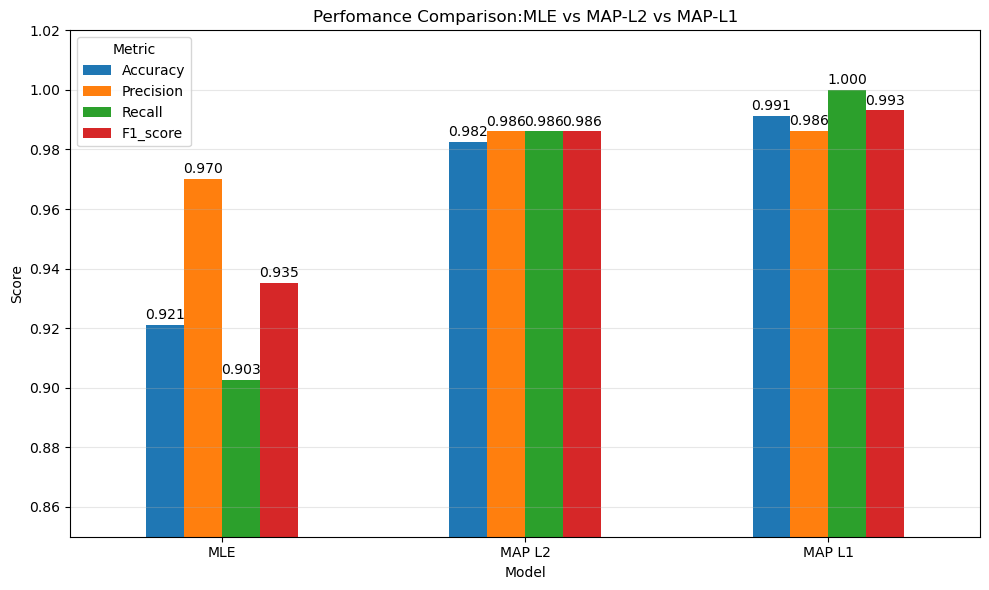

In [28]:
ax=results.set_index("Model").plot(
  kind="bar",
  figsize=(10,6)
)
plt.title("Perfomance Comparison:MLE vs MAP-L2 vs MAP-L1")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.85,1.02)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y",alpha=0.3)
for container in ax.containers:
    ax.bar_label(container,fmt="%.3f",padding=2)
plt.tight_layout()
plt.show()
